In [96]:
import numpy as np
import matplotlib.pyplot as plt

def get_direct_neighbors(grid, x, y):
    """Get direct neighbors (north, south, east, west)."""
    neighbors = []
    grid_size = grid.shape[0]
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nx, ny = x + dx, y + dy
        if 0 <= nx < grid_size and 0 <= ny < grid_size:
            neighbors.append(grid[nx, ny])
    return neighbors

def is_satisfied(grid, x, y, tolerance):
    """Check if agent is satisfied with its neighborhood."""
    agent = grid[x, y]
    if agent == 0:
        return True
    
    neighbors = get_direct_neighbors(grid, x, y)
    if not neighbors:
        return False
    
    same_type = sum(1 for n in neighbors if n == agent)
    return same_type / len(neighbors) >= tolerance

def initialize_grid(grid_size=50, density=0.75):
    """Initialize the grid with agents of type 1 and 2."""
    num_cells = grid_size**2
    num_agents = int(num_cells * density)
    num_agents = (num_agents // 2) * 2  # Ensure even number of agents
    
    # Create balanced array of agents
    agents = np.zeros(num_cells, dtype=np.int8)
    agents[:num_agents//2] = 1
    agents[num_agents//2:num_agents] = 2
    
    # Shuffle and reshape
    np.random.shuffle(agents)
    grid = agents.reshape(grid_size, grid_size)
    
    # Pre-compute empty spots
    empty_spots = set((x, y) for x in range(grid_size) for y in range(grid_size) if grid[x, y] == 0)
    
    return grid, empty_spots

def getRandomAgent(grid, unhappy_agents):
    """Select a random unhappy agent."""
    if not unhappy_agents:
        return None
    return list(unhappy_agents)[np.random.randint(0, len(unhappy_agents))]

def step(agent, grid, tolerance, empty_spots, unhappy_agents):
    """Move an agent to a new location if unhappy."""
    if agent is None:
        return grid, empty_spots, unhappy_agents, False
        
    x, y = agent
    grid_size = grid.shape[0]
    
    # Skip if the agent became happy since being added to the list
    if is_satisfied(grid, x, y, tolerance) or grid[x, y] == 0:
        unhappy_agents.remove(agent)
        return grid, empty_spots, unhappy_agents, False
    
    # Move agent if empty spots exist
    if empty_spots:
        # Select random empty spot
        new_x, new_y = list(empty_spots)[np.random.randint(0, len(empty_spots))]
        
        # Move the agent
        agent_type = grid[x, y]
        grid[new_x, new_y] = agent_type
        grid[x, y] = 0
        
        # Update empty spots
        empty_spots.remove((new_x, new_y))
        empty_spots.add((x, y))
        
        # Remove from unhappy list
        unhappy_agents.remove((x, y))
        
        # Check if agent is happy at new location
        if not is_satisfied(grid, new_x, new_y, tolerance):
            unhappy_agents.add((new_x, new_y))
        
        # Check if neighbors of old location are now unhappy
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if (0 <= nx < grid_size and 0 <= ny < grid_size and 
                grid[nx, ny] != 0):
                if is_satisfied(grid, nx, ny, tolerance):
                    # Remove from unhappy if it was there
                    unhappy_agents.discard((nx, ny))
                else:
                    # Add to unhappy if not already there
                    unhappy_agents.add((nx, ny))
        
        # Check if neighbors of new location are now unhappy
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = new_x + dx, new_y + dy
            if (0 <= nx < grid_size and 0 <= ny < grid_size and 
                grid[nx, ny] != 0):
                if is_satisfied(grid, nx, ny, tolerance):
                    # Remove from unhappy if it was there
                    unhappy_agents.discard((nx, ny))
                else:
                    # Add to unhappy if not already there
                    unhappy_agents.add((nx, ny))
        
        return grid, empty_spots, unhappy_agents, True
    
    return grid, empty_spots, unhappy_agents, False

def plot_grid(grid, iteration, cmap):
    """Plot the grid at a given iteration."""
    plt.figure(figsize=(6, 6))
    plt.imshow(grid, cmap=cmap, vmin=0, vmax=2)
    plt.title(f'Iteration: {iteration}')
    plt.show(block=False)
    plt.pause(0.1)
    print(f"Created plot for iteration {iteration}")

def run_schelling_simulation(grid_size=50, density=0.75, tolerance=0.3, max_iterations=10000, plot=True):
    """Run the Schelling segregation model simulation with initial, 1000th and final plots."""
    # Initialize the grid
    grid, empty_spots = initialize_grid(grid_size, density)
    
    # Set up plotting
    cmap = plt.cm.colors.ListedColormap(['white', 'green', 'blue'])
    
    # Store unhappy agents rather than checking all agents each time
    unhappy_agents = set()
    for x in range(grid_size):
        for y in range(grid_size):
            if grid[x, y] != 0 and not is_satisfied(grid, x, y, tolerance):
                unhappy_agents.add((x, y))
    
    # Plot initial state (iteration 0)
    if plot:
        plot_grid(grid, 0, cmap)
    
    # Main simulation loop
    iteration = 0

    unhappy_agents_history = []

    while iteration < max_iterations:
        # Get a random unhappy agent
        agent = getRandomAgent(grid, unhappy_agents)
        
        # No more unhappy agents
        if agent is None:
            break
        
        # Perform a step of the simulation
        grid, empty_spots, unhappy_agents, has_moved = step(agent, grid, tolerance, empty_spots, unhappy_agents)

        # Only increment iteration counter if an agent actually moved
        if has_moved:
            iteration += 1
            
            # Plot at 1000th iteration
            if iteration == 1000:
                if plot:
                    plot_grid(grid, 1000, cmap)
        unhappy_agents_history.append(len(list(unhappy_agents)))

    if plot:
    # Print final iteration count and reason for termination
        if iteration >= max_iterations:
            print(f"Reached maximum iteration limit: {max_iterations}")
        elif not unhappy_agents:
            print(f"All agents are satisfied - equilibrium reached at iteration {iteration}")

    if plot:
    # Plot final state if it's not the same as the 1000th iteration
        if iteration != 1000:
            plot_grid(grid, iteration, cmap)

        # Make sure all plots are shown
        plt.show()
    
    # Return final state
    return unhappy_agents_history, grid

In [97]:
#run_schelling_simulation(grid_size=50, density=0.85, tolerance=0.3, max_iterations=10000)
#run_schelling_simulation(grid_size=50, density=0.85, tolerance=0.25, max_iterations=10000)
data, grid = run_schelling_simulation(grid_size=50, density=0.95, tolerance=0.26, plot=False)
#runSchellingSimulation(grid_size=50, density=0.75, tolerance=0.25)

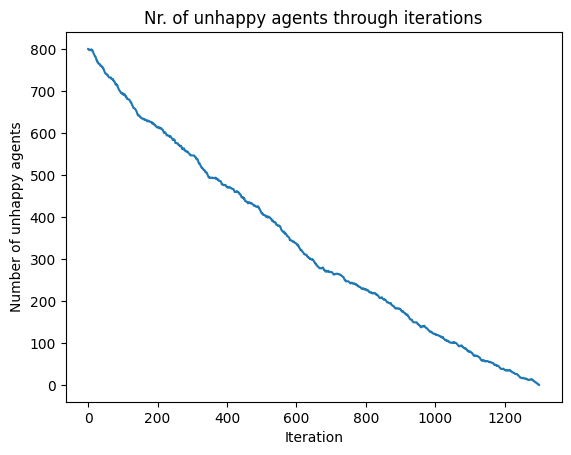

In [98]:
plt.plot(data)
plt.xlabel('Iteration')
plt.ylabel('Number of unhappy agents')
plt.title('Nr. of unhappy agents through iterations')
plt.show()

In [99]:
def wykres_tolerancji(step, density, grid_size=20):
    """
    oblicza/tworzy wykres dla symulacji puszczonej jeden raz na krok tolerancji
    """
    unsatf_list = []
    xi = []
    for i in range(1, int(1/step + 1)):
        #print(i*step)#tutaj biore for'a od 1 bo tolerancja dla 0 to jakies dziwne rzeczy wychodza, do sprawdzenia czemu tak
        unsatf_agents, grid = run_schelling_simulation(grid_size=grid_size, density=density, tolerance=i*step, plot=False)
        unsatf_list.append(unsatf_agents[-1])
        xi.append(i*step)

    return unsatf_list, xi

In [100]:
wykres_tolerancji(0.01, 0.85, grid_size=40)

([0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  388,
  355,
  329,
  383,
  386,
  375,
  372,
  317,
  362,
  392,
  365,
  319,
  342,
  343,
  392,
  384,
  445,
  489,
  454,
  445,
  447,
  441,
  442,
  483,
  451,
  1265,
  1285,
  1282,
  1289,
  1268,
  1294,
  1273,
  1266,
  1271,
  1277,
  1286,
  1298,
  1280,
  1303,
  1290,
  1288,
  1278,
  1280,
  1285,
  1289,
  1288,
  1280,
  1285,
  1282,
  1282],
 [0.01,
  0.02,
  0.03,
  0.04,
  0.05,
  0.06,
  0.07,
  0.08,
  0.09,
  0.1,
  0.11,
  0.12,
  0.13,
  0.14,
  0.15,
  0.16,
  0.17,
  0.18,
  0.19,
  0.2,
  0.21,
  0.22,
  0.23,
  0.24,
  0.25,
  0.26,
  0.27,
  0.28,
  0.29,
  0.3,
  0.31,
  0.32,
  0.33,
  0.34,
  0.35000000000000003,
  0.36,
  0.37,
  0.38,
  0.39,
  0.4,
  0.41000000000000003,
  0.42,
  0.43,
  0.

In [101]:
def srednia_tolerancji(step, density, grid_size=20, size=5):
    """
    step: okresla co jaki krok zmienia sie tolerancja
    size: z ilu symulacji liczymy srednia dla jednego kroku
    """
    lista_xi = []
    all_unsatf_list = []
    print(f'Spodziewany czas to {size} * czas_jednej_symluacji')
    for i in range(size + 1):
        print(i)
        unsatf_list, xi_lisy = wykres_tolerancji(step, density, grid_size)
        all_unsatf_list.append(unsatf_list)
        lista_xi.append(xi_lisy)

    return all_unsatf_list, lista_xi

Spodziewany czas to 100.0 * czas_jednej_symluacji
0
1
2
3
4
5
6
7
8
9
10


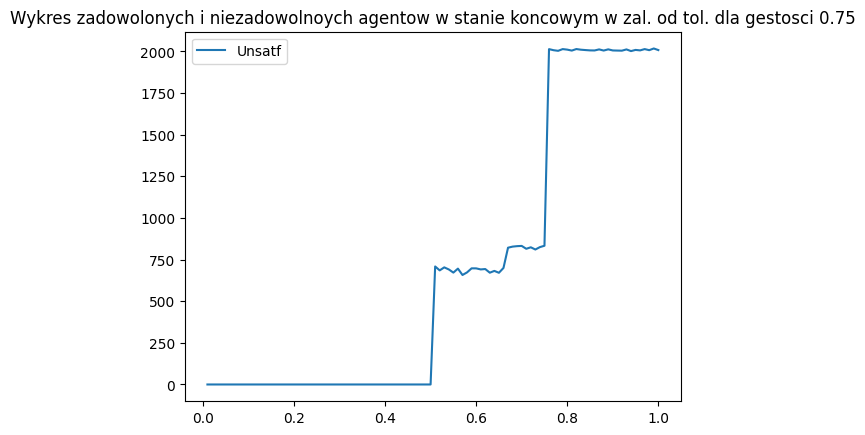

In [102]:
density = 0.85
grid_size = 50
step_size = 0.01
number_average = 10

unsatf, lista_xi = srednia_tolerancji(step_size, density, grid_size, number_average) #TODO: tutaj odpalic jak najmniejszy step i grid_size 50 i size 10
mean_unsatf = np.mean(unsatf, axis=0)

plt.plot(lista_xi[0], mean_unsatf, label="Unsatf")
plt.title("Wykres zadowolonych i niezadowolnoych agentow w stanie koncowym w zal. od tol. dla gestosci 0.75")
plt.legend()
plt.show()

In [103]:
class UnionFind:
    #to jest algorytm ktory laczy dwa elementy jezeli powinny byc w tej samej grupie w naszym przypadku kolorze
    def __init__(self, size):
        self.parent = list(range(size))
        self.rank = [0] * size

    #funkcja find sprawdza jaki jest "parent", czyli reprezentat grupy
    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    # funkcja union po prostu scala dwie komorki jezeli nie maja tego samego reprezentanta w zaleznosci
    # od rangi jeden dolaczany jest do drugiego lub na odwrot
    def union(self, x, y):
        rx = self.find(x)
        ry = self.find(y)
        if rx != ry:
            if self.rank[rx] < self.rank[ry]:
                self.parent[rx] = ry
            elif self.rank[rx] > self.rank[ry]:
                self.parent[ry] = rx
            else:
                self.parent[ry] = rx
                self.rank[rx] += 1

In [104]:
def hoshen_kopelman(grid, val):

    # w tym algorytmie bedzie sprawdzac sasiadow kazdej komorki
    # tworzymy siatke wypelniona zerami

    rows = len(grid)
    cols = len(grid[0]) if rows > 0 else 0

    labels = [[0]*cols for _ in range(rows)]

    #tworzymy ta klase ktora potem wykorzystamy do laczenia grup agentow

    uf = UnionFind(rows * cols + 1)  # +1, by mieć 'bezpieczne' indeksy od 1 w górę
    current_label = 0

    # Pomocnicza funkcja do przekształcania (i, j) w indeks union-find
    def idx(i, j):
        return i * cols + j + 1  # +1 żeby 0 mieć "zarezerwowane" np. dla braku

    # przechodzimy po kazdej komorce i sprawdzamy sasiadow gornego i lewego, jezeli obaj maja 1 to
    for i in range(rows):
        for j in range(cols):

            if grid[i][j] == val:
                up_label = labels[i-1][j] if i > 0 else 0
                left_label = labels[i][j-1] if j > 0 else 0

                if up_label == 0 and left_label == 0:
                    # Nowy klaster
                    current_label += 1
                    labels[i][j] = current_label

                elif up_label != 0 and left_label == 0:
                    labels[i][j] = up_label

                elif up_label == 0 and left_label != 0:
                    labels[i][j] = left_label

                else:
                    # Oba są != 0 to bierzemy mniejszy i scalamy komorki
                    chosen_label = min(up_label, left_label)
                    labels[i][j] = chosen_label
                    uf.union(up_label, left_label)
            else:
                labels[i][j] = 0

    for i in range(rows):
        for j in range(cols):
            if labels[i][j] != 0:
                # reprezentant w union-find
                root_label = uf.find(labels[i][j])
                # Nadpisz w tablicy
                labels[i][j] = root_label

    return labels

In [105]:
def hoshen_kopelman_2groups(grid):
    labels_plus = hoshen_kopelman(grid, 1)
    labels_minus = hoshen_kopelman(grid, 2)
    return labels_plus, labels_minus

In [106]:
from collections import Counter

In [107]:
def calculateS(label1, label2):
    cluster_sizes1 = Counter()
    rows1 = len(label1)
    cols1 = len(label1[0]) if rows1 > 0 else 0
    for i in range(rows1):
        for j in range(cols1):
            c1 = label1[i][j]
            if c1 != 0:
                cluster_sizes1[c1] += 1

    cluster_sizes2 = Counter()
    rows2 = len(label2)
    cols2 = len(label2[0]) if rows2 > 0 else 0
    for i in range(rows2):
        for j in range(cols2):
            c2 = label2[i][j]
            if c2 != 0:
                cluster_sizes2[c2] += 1

    N_agents1 = sum(cluster_sizes2.values())
    N_agents2 = sum(cluster_sizes2.values())

    N_tot = N_agents1 + N_agents2

    sum_sq1 = sum((sz * sz) for sz in cluster_sizes1.values())
    sum_sq2 = sum((sz * sz) for sz in cluster_sizes1.values())

    sq_tot = sum_sq1 + sum_sq2

    s_value = 2.0 * sq_tot / (N_tot * N_tot)
    return s_value


In [108]:
def simulation_of_S(grid_size=20, density=0.95, step_size=0.1):

    s_list = []
    tol_list = []

    for i in range(1, int(1/step_size + 1)):

        print(i*step_size)
        tol_list.append(i*step_size)

        unsatfTEMP, grid = run_schelling_simulation(grid_size=grid_size, density=density, tolerance=i*step_size, plot=False)
        lp, lm = hoshen_kopelman_2groups(grid)
        s_list.append(calculateS(lp, lm))

    return s_list, tol_list

0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.31
0.32
0.33
0.34
0.35000000000000003
0.36
0.37
0.38
0.39
0.4
0.41000000000000003
0.42
0.43
0.44
0.45
0.46
0.47000000000000003
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.5700000000000001
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.6900000000000001
0.7000000000000001
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.8200000000000001
0.8300000000000001
0.84
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.9400000000000001
0.9500000000000001
0.96
0.97
0.98
0.99
1.0


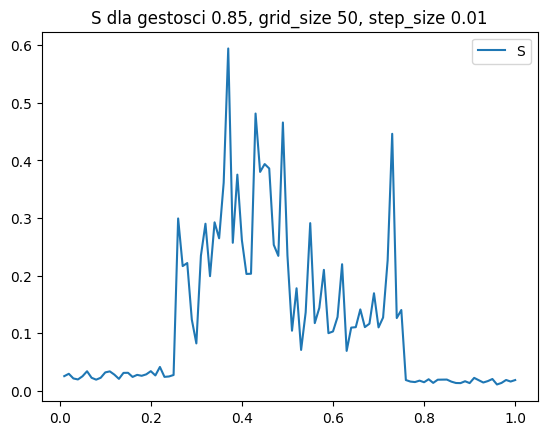

In [109]:
density_s = 0.85
grid_size_s = 40
step_size_s = 0.01

s, tol = simulation_of_S(grid_size=grid_size, density=density, step_size=step_size)
plt.plot(tol, s, label="S")
plt.legend()
plt.title(f'S dla gestosci {density}, grid_size {grid_size}, step_size {step_size}')
plt.show()